In [1]:
# ==========================================
# 1. Data Loading
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/ML/train.csv")

df.head()

Mounted at /content/drive


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [2]:
# ==========================================
# 2. Data Preprocessing / Cleaning
# ==========================================

# Remove missing values
df = df.dropna()

# Check dataset information
print(df.info())

# Show first 5 rows
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 10442 entries, 0 to 10442
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   experience    10442 non-null  float64
 1   country       10442 non-null  object 
 2   education     10442 non-null  object 
 3   languages     10442 non-null  object 
 4   frameworks    10442 non-null  object 
 5   company_size  10442 non-null  object 
 6   salary_usd    10442 non-null  int64  
dtypes: float64(1), int64(1), object(5)
memory usage: 652.6+ KB
None


,experience,country,education,languages,frameworks,company_size,salary_usd
0,34.0,Germany,Masters,"Rust, JavaScript","Vue, ASP.NET",201-1000,172292
1,9.0,UK,Masters,"C#, JavaScript","Ruby on Rails, Spring",201-1000,82311
2,8.0,USA,Some College,"C++, Go","Vue, React",5000+,109637
3,29.0,USA,Masters,"C++, Ruby","Spring, Angular",Nov-50,214386
4,7.0,USA,Bachelors,"C#, Rust","React, Express",10-Jan,107584


In [4]:
# ==========================================
# 3. Feature Selection
# ==========================================

X = df.drop('salary_usd', axis=1)
y = df['salary_usd']

categorical_features = ['country', 'education', 'languages', 'frameworks', 'company_size']
numeric_features = ['experience']

In [5]:
# ==========================================
# 4. Train Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (8353, 6)
Testing Data Shape: (2089, 6)


In [6]:
# ==========================================
# 5. Normalization and Encoding
# ==========================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features)
    ]
)

In [7]:
# ==========================================
# 6. Linear Regression Model Training
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

print("Linear Regression model training completed.")

Linear Regression model training completed.


In [8]:
# ==========================================
# 7. Prediction
# ==========================================

y_pred = model.predict(X_test)

sample_output = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

sample_output.head(15)

,Actual Salary,Predicted Salary
0,58331,67222.158991
1,80213,90208.686174
2,133929,119760.935751
3,98293,96669.995755
4,128384,108142.430053
5,115152,103317.771592
6,213693,196963.286283
7,94038,86081.612866
8,194017,166762.620226
9,136000,131356.183402


In [9]:
# ==========================================
# 8. Error Metrics
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2 Score'],
    'Value': [mae, mse, rmse, r2]
})

metrics_df

,Metric,Value
0,MAE,1.324827e+04
1,MSE,2.611949e+08
2,RMSE,1.616153e+04
3,R2 Score,8.761469e-01


In [10]:
# ==========================================
# 9. Sample Predictions / Output
# ==========================================

sample_predictions = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred,
    'Difference': y_test.values - y_pred
})

sample_predictions.head(15)

,Actual Salary,Predicted Salary,Difference
0,58331,67222.158991,-8891.158991
1,80213,90208.686174,-9995.686174
2,133929,119760.935751,14168.064249
3,98293,96669.995755,1623.004245
4,128384,108142.430053,20241.569947
5,115152,103317.771592,11834.228408
6,213693,196963.286283,16729.713717
7,94038,86081.612866,7956.387134
8,194017,166762.620226,27254.379774
9,136000,131356.183402,4643.816598


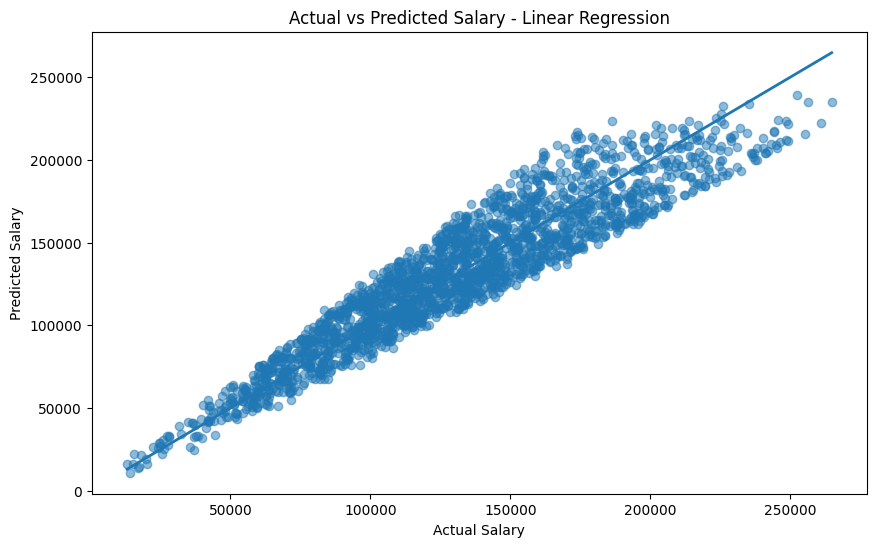

In [11]:
# ==========================================
# 10. Actual vs Predicted Salary
# ==========================================

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2
)

plt.title("Actual vs Predicted Salary - Linear Regression")
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.show()

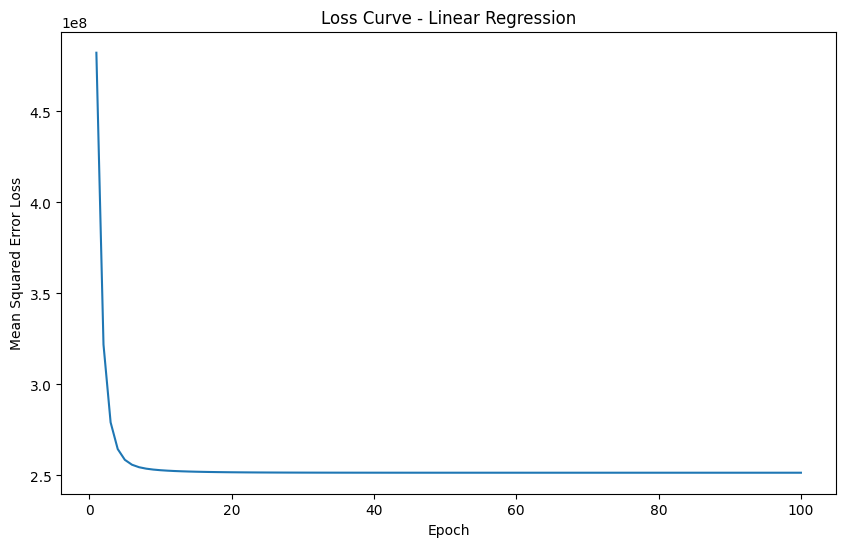

In [14]:
# ==========================================
# 11. Loss Curve using SGD Linear Regression
# ==========================================

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning

# Suppress ConvergenceWarning from SGDRegressor as max_iter=1 is intentional for epoch tracking
warnings.filterwarnings('ignore', category=ConvergenceWarning)

# Preprocess data manually for SGDRegressor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

sgd_model = SGDRegressor(
    max_iter=1,
    warm_start=True,
    learning_rate='constant',
    eta0=0.001,
    random_state=42
)

losses = []

for epoch in range(1, 101):
    sgd_model.fit(X_train_processed, y_train)
    y_train_pred = sgd_model.predict(X_train_processed)
    loss = mean_squared_error(y_train, y_train_pred)
    losses.append(loss)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 101), losses)
plt.title("Loss Curve - Linear Regression")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error Loss")
plt.show()

# Reset warnings to default behavior after this cell
warnings.filterwarnings('default', category=ConvergenceWarning)

In [13]:
# ==========================================
# 12. Predict New Output
# ==========================================

new_data = pd.DataFrame({
    'experience': [5],
    'country': ['USA'],
    'education': ['Bachelor'],
    'languages': ['Python'],
    'frameworks': ['Django'],
    'company_size': ['201-1000']
})

predicted_salary = model.predict(new_data)

print("Predicted Salary USD:", predicted_salary[0])

Predicted Salary USD: 110716.03166654002


In [ ]:
# Conclusion:
# The Linear Regression model was successfully implemented on the Software Developer Salary Prediction dataset.
# Data preprocessing, cleaning, normalization, feature selection, and model training were performed in Google Colab.
# The model predicted salary_usd using experience, country, education, languages, frameworks, and company_size.
# The model performance was evaluated using MAE, MSE, RMSE, and R2 Score.
# A loss curve and sample predictions were generated to show the model training behavior and prediction output.